# 02 Test YOLO26n

This notebook tests the YOLO26n baseline method on the payload loss test dataset. YOLO detects objects in each frame, and payload loss is inferred when the current object count drops compared to the initial object count.

## 1. Imports and setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.utils import GROUND_TRUTH_CSV, resolve_test_video_path
from src.yolo_method import YOLOMethod
from src.evaluate import evaluate_method

## 2. Load Ground Truth

Load the test dataset annotations from `ground_truth.csv`.

In [2]:
gt = pd.read_csv(GROUND_TRUTH_CSV)
gt.head()

,filename,camera_id,is_loss_event,loss_frame,total_frames
0,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,410
1,videos_normal/indoor_full/back_empty_001.mp4,back,0,-1,408
2,videos_normal/indoor_full/left_empty_001.mp4,left,0,-1,406
3,videos_normal/indoor_full/right_empty_001.mp4,right,0,-1,404
4,videos_normal/indoor_med/front_empty_001.mp4,front,0,-1,411


## 3. Inspect One Video

Select one video from the dataset and run YOLO26n on it to check whether the object count changes around the payload loss event.

In [3]:
row = gt.iloc[0]
video_path = resolve_test_video_path(row["filename"])

row, video_path

(filename         videos_normal/indoor_full/front_empty_001.mp4
 camera_id                                                front
 is_loss_event                                                0
 loss_frame                                                  -1
 total_frames                                               410
 Name: 0, dtype: object,
 PosixPath('/Users/tohjiale/Desktop/payload_loss_detection/test_data/videos_normal/indoor_full/front_empty_001.mp4'))

### 4. Test YOLO26n on one video

In [5]:
method = YOLOMethod(conf_threshold=0.25, count_drop_threshold=1, consecutive_frames=5)
result = method.predict_video(video_path)

print("Detected frame:", result["detected_frame"])
print("Ground truth loss frame:", row["loss_frame"])

Detected frame: -1
Ground truth loss frame: -1


## 5. Plot Object Count

The plot shows YOLO26n object count over time. Payload loss is inferred when the object count drops below the initial count.

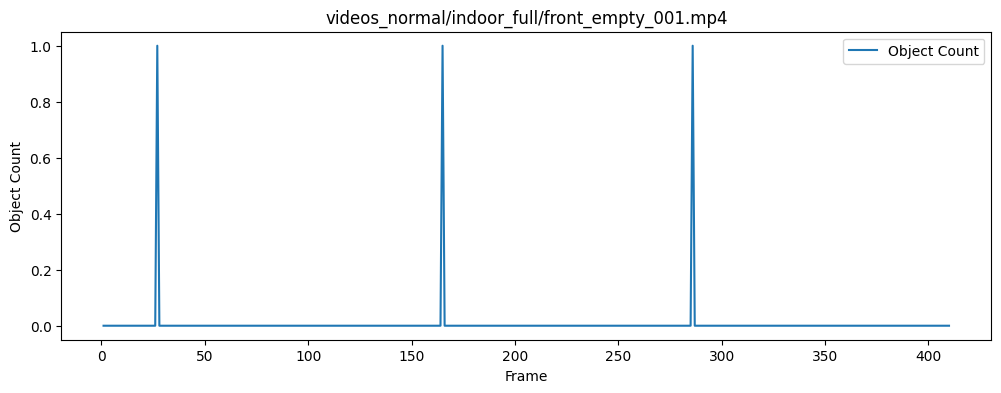

In [6]:
frames = list(range(1, len(result["object_counts"]) + 1))

plt.figure(figsize=(12, 4))
plt.plot(frames, result["object_counts"], label="Object Count")

if row["is_loss_event"] == 1:
    plt.axvline(row["loss_frame"], linestyle="--", label="Ground Truth Loss Frame")

if result["detected_frame"] != -1:
    plt.axvline(result["detected_frame"], linestyle=":", label="Detected Frame")

plt.xlabel("Frame")
plt.ylabel("Object Count")
plt.title(row["filename"])
plt.legend()
plt.show()

## 6. Evaluate YOLO26n on Full Test Dataset

Run YOLO26n on all test videos and compute event-level, frame-level, and latency metrics.

In [7]:
method = YOLOMethod(conf_threshold=0.25, count_drop_threshold=1, consecutive_frames=5)

video_results, frame_results, metrics = evaluate_method(method)

metrics

{'event_level_recall': np.float64(0.06944444444444445),
 'event_level_precision': np.float64(0.17857142857142858),
 'frame_level_precision': np.float64(0.574050471577874),
 'avg_detection_delay_frames': np.float64(23.2),
 'avg_latency_ms': np.float64(26.060097570898034)}

### Video-Level Results

Preview of evaluation results at the video level, including detected frame and ground truth labels.

In [8]:
video_results.head()

,filename,camera_id,is_loss_event,loss_frame,total_frames,detected_frame
0,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,410,-1
1,videos_normal/indoor_full/back_empty_001.mp4,back,0,-1,408,-1
2,videos_normal/indoor_full/left_empty_001.mp4,left,0,-1,406,-1
3,videos_normal/indoor_full/right_empty_001.mp4,right,0,-1,404,-1
4,videos_normal/indoor_med/front_empty_001.mp4,front,0,-1,411,-1


### Frame-Level Results

Preview of per-frame predictions, scores, and inference latency for all videos.

In [ ]:
frame_results.head()

## 7. Confidence Threshold Sweep

YOLO requires a confidence threshold to filter detections. This section tests multiple confidence thresholds and compares their metrics.

In [9]:
sweep_results = []

conf_thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

for conf in conf_thresholds:
    method = YOLOMethod(conf_threshold=conf, count_drop_threshold=1, consecutive_frames=5)
    _, _, metrics = evaluate_method(method)

    sweep_results.append({
        "conf_threshold": conf,
        **metrics
    })

sweep_df = pd.DataFrame(sweep_results)
sweep_df

,conf_threshold,event_level_recall,event_level_precision,frame_level_precision,avg_detection_delay_frames,avg_latency_ms
0,0.10,0.208333,0.211268,0.518266,3.866667,25.537925
1,0.15,0.166667,0.250000,0.576523,-0.083333,26.476212
2,0.20,0.083333,0.171429,0.591006,-0.500000,27.869136
3,0.25,0.069444,0.178571,0.574050,23.200000,31.950013
4,0.30,0.041667,0.125000,0.651284,30.000000,32.479630
5,0.40,0.027778,0.153846,0.709384,-29.000000,32.688677
6,0.50,0.013889,0.111111,0.734763,-33.000000,32.778607


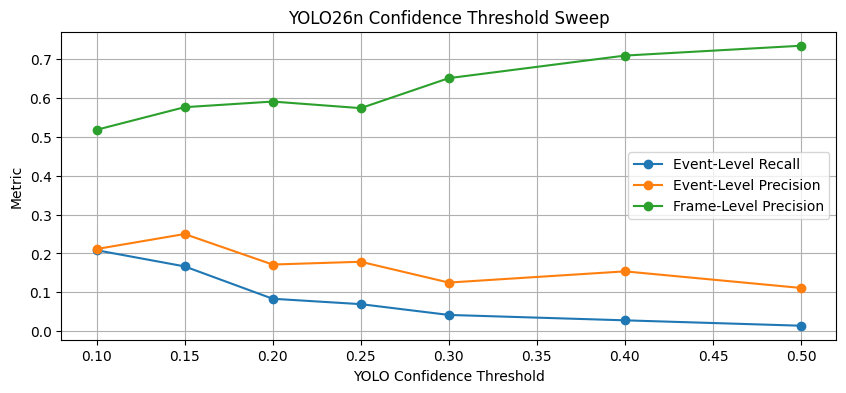

In [16]:
# Plot threshold sweep

plt.figure(figsize=(10, 4))
plt.plot(sweep_df["conf_threshold"], sweep_df["event_level_recall"], marker="o", label="Event-Level Recall")
plt.plot(sweep_df["conf_threshold"], sweep_df["event_level_precision"], marker="o", label="Event-Level Precision")
plt.plot(sweep_df["conf_threshold"], sweep_df["frame_level_precision"], marker="o", label="Frame-Level Precision")

plt.xlabel("YOLO Confidence Threshold")
plt.ylabel("Metric")
plt.title("YOLO26n Confidence Threshold Sweep")
plt.legend()
plt.grid(True)
# plt.savefig("results/fig10_yolo_threshold_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Save Results

Save YOLO26n results for later comparison with SSIM and the Siamese network.

In [14]:
output_dir = PROJECT_ROOT / "notebooks" / "results"
output_dir.mkdir(exist_ok=True)

video_results.to_csv(output_dir / "yolo_video_results.csv", index=False)
frame_results.to_csv(output_dir / "yolo_frame_results.csv", index=False)
sweep_df.to_csv(output_dir / "yolo_conf_threshold_sweep.csv", index=False)

print("Saved YOLO26n results.")

Saved YOLO26n results.


## 9. Conclusion

YOLO26n performance is poor across all tested confidence thresholds. The best-performing configuration at a confidence threshold of 0.10 achieves an event-level recall of 20.8% and frame-level precision of 51.8%, which is insufficient for reliable payload loss detection. Event-level precision is also low at 21.1%, indicating a high number of false positives despite already missing most true loss events.

Across thresholds, YOLO26n exhibits a clear trade-off between recall and precision. Lower confidence thresholds slightly improve recall but introduce unstable object detections, while higher thresholds reduce false positives at the cost of missing nearly all loss events. The object count signal is highly inconsistent, even in normal-operation videos where no payload is present, resulting in spurious detections and noisy predictions. Detection delay is also unreliable, with large variations depending on threshold settings, further limiting its practical use.

Additional temporal filtering was not explored further as the primary limitation was poor detection capability due to mismatched object classes rather than noisy predictions.

Overall, YOLO26n is not suitable for this application without task-specific fine-tuning. Its reliance on the COCO dataset limits its ability to detect relevant payload items such as toolboxes, and the resulting object count is too unstable for dependable change detection. In addition, its relatively high inference latency (~25–33 ms per frame) makes it less suitable for real-time deployment on constrained hardware compared to lighter methods.